In [376]:
%matplotlib inline
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import heapq
import random

### 1. Warehouse Map

- กำหนดโครงสร้างแผนที่ตารางกริดของคลังสินค้า

In [377]:
warehouse = np.array([
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0]
])

### 2. Coordinate Validation

- ตรวจสอบความถูกต้องของตำแหน่งทางเข้า ทางออก และชั้นวางสินค้า

In [378]:
def validate_points(warehouse, entrance, exit_point, pickup_points):
    if warehouse[entrance] != 0: raise ValueError("Entrance must be on walkway (0)")
    if warehouse[exit_point] != 0: raise ValueError("Exit must be on walkway (0)")
    for point in pickup_points:
        if warehouse[point] != 1: raise ValueError(f"Pickup point {point} must be on shelf (1)")

### 3. Random Pickup Point Generation

- สุ่มจุดหยิบสินค้าตามจำนวนที่ต้องการพร้อมล็อกค่า seed

In [379]:
def generate_pickup_points(warehouse, n, seed=42):
    shelf_positions = list(zip(*np.where(warehouse == 1)))
    rng = np.random.default_rng(seed)
    selected_indices = rng.choice(len(shelf_positions), size=n, replace=False)
    return [shelf_positions[index] for index in selected_indices]

### 4. Warehouse Map Visualization

- ฟังก์ชันแปลงข้อมูลเป็นภาพกราฟิก

In [380]:
def plot_warehouse(warehouse, entrance, exit_point, pickup_points):
    rows, cols = warehouse.shape
    colors = ["#EAF6FF", "#4A4A4A"]
    warehouse_cmap = ListedColormap(colors)
    plt.figure(figsize=(12, 8))
    plt.imshow(warehouse, cmap=warehouse_cmap, origin="upper", interpolation="nearest")
    
    plt.scatter(entrance[1], entrance[0], color="#27AE60", s=220, edgecolors="black", zorder=3)
    plt.text(entrance[1], entrance[0], "IN", ha="center", va="center", color="white", fontweight="bold", fontsize=8, zorder=4)
    
    plt.scatter(exit_point[1], exit_point[0], color="#E74C3C", s=220, edgecolors="black", zorder=3)
    plt.text(exit_point[1], exit_point[0], "OUT", ha="center", va="center", color="white", fontweight="bold", fontsize=7, zorder=4)
    
    for index, point in enumerate(pickup_points, start=1):
        plt.scatter(point[1], point[0], color="#F1C40F", s=180, marker="s", edgecolors="black", zorder=3)
        plt.text(point[1], point[0], str(index), ha="center", va="center", fontweight="bold", color="black", zorder=4)

    plt.xticks(np.arange(-0.5, cols, 1), minor=True)
    plt.yticks(np.arange(-0.5, rows, 1), minor=True)
    plt.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    plt.title("Warehouse Map with Entrance, Exit and Pickup Points", fontsize=14, fontweight="bold")
    
    legend_elements = [
        Patch(facecolor="#EAF6FF", edgecolor="black", label="Walkway (0)"),
        Patch(facecolor="#4A4A4A", edgecolor="black", label="Shelf (1)"),
        plt.Line2D([0], [0], marker="o", color="w", label="Entrance", markerfacecolor="#27AE60", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Exit", markerfacecolor="#E74C3C", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="s", color="w", label="Pickup Point", markerfacecolor="#F1C40F", markeredgecolor="black", markersize=10)
    ]
    
    plt.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=5)
    plt.show()

### 5. Initialize Coordinates and Display Map

- แสดงภาพแผนที่

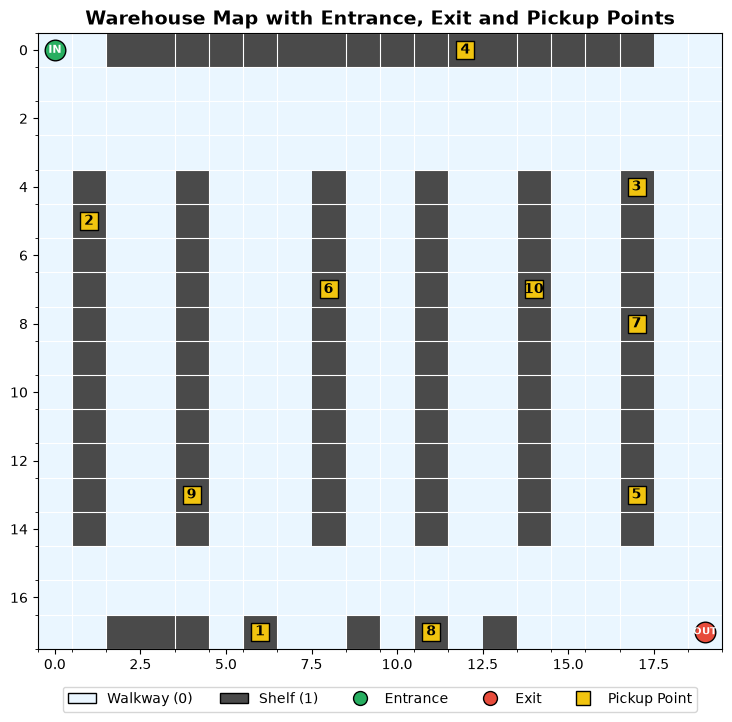

In [381]:
entrance = (0, 0)
exit_point = (17, 19)
n = 10

pickup_points = generate_pickup_points(warehouse=warehouse, n=n, seed=20)

validate_points(warehouse, entrance, exit_point, pickup_points)  
plot_warehouse(warehouse, entrance, exit_point, pickup_points) 

### 6. Print Pickup Coordinates

- แสดงพิกัดตัวเลข (Row, Column) ของจุดหยิบสินค้าทั้งหมด

In [382]:
print("Entrance:", entrance)
print("Exit:", exit_point)
for index, point in enumerate(pickup_points, start=1):
    print(f"  Pickup {index}: ({int(point[0])}, {int(point[1])})")

Entrance: (0, 0)
Exit: (17, 19)
  Pickup 1: (17, 6)
  Pickup 2: (5, 1)
  Pickup 3: (4, 17)
  Pickup 4: (0, 12)
  Pickup 5: (13, 17)
  Pickup 6: (7, 8)
  Pickup 7: (8, 17)
  Pickup 8: (17, 11)
  Pickup 9: (13, 4)
  Pickup 10: (7, 14)


## A* Search Algorithm and Distance Matrix

### 1. Stand Position Finder

- ค้นหาพิกัดจุดยืนหยิบสินค้าที่อยู่ติดกับชั้นวางสินค้า เพื่อเตรียมให้พนักงานยืนหยิบของ

In [383]:
def get_valid_stand_positions(warehouse, item_pos):
    stand_positions = []
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    for dr, dc in directions:
        nr, nc = item_pos[0] + dr, item_pos[1] + dc
        if 0 <= nr < warehouse.shape[0] and 0 <= nc < warehouse.shape[1]:
            if warehouse[nr, nc] == 0:
                stand_positions.append((nr, nc))
    return stand_positions

### 2. Shortest Path Calculation

- ใช้ A* Search คำนวณหาเส้นทางและระยะทางที่สั้นที่สุดบนแผนที่ตารางกริดระหว่างจุดเริ่มต้นและจุดหมาย

In [384]:
def a_star_search(warehouse, starts, targets):
    def heuristic(pos):
        return min(abs(pos[0] - t[0]) + abs(pos[1] - t[1]) for t in targets)
    
    pq = []
    visited = set()
    counter = 0 
    for st in starts:
        heapq.heappush(pq, (heuristic(st), 0, counter, st, [st]))
        counter += 1
        
    while pq:
        f, g, _, curr, path = heapq.heappop(pq)
        
        if curr in targets:
            return g, path
            
        if curr in visited:
            continue
        visited.add(curr)
        
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = curr[0] + dr, curr[1] + dc
            if 0 <= nr < warehouse.shape[0] and 0 <= nc < warehouse.shape[1]:
                if warehouse[nr, nc] == 0 and (nr, nc) not in visited:
                    new_g = g + 1
                    new_f = new_g + heuristic((nr, nc))
                    heapq.heappush(pq, (new_f, new_g, counter, (nr, nc), path + [(nr, nc)]))
                    counter += 1
    return float('inf'), []

### 3. Distance Matrix Generator

- ฟังก์ชันรวบรวมโหนดสำคัญทั้งหมด (ทางเข้า, จุดหยิบสินค้า, ทางออก) 

- นำ A* Search มาใช้งานเพื่อคำนวณตารางระยะทางจริงระหว่างทุกๆ จุด

In [385]:
def build_distance_matrix(warehouse, entrance, exit_point, pickup_points):
    all_nodes = [entrance] + pickup_points + [exit_point]
    num_nodes = len(all_nodes)
    dist_matrix = np.zeros((num_nodes, num_nodes))
    valid_positions = []
    
    for i, node in enumerate(all_nodes):
        if i == 0 or i == num_nodes - 1:
            valid_positions.append([node])
        else:
            valid_positions.append(get_valid_stand_positions(warehouse, node))
            
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                dist_matrix[i][j] = 0
            elif i < j:
                dist, _ = a_star_search(warehouse, valid_positions[i], valid_positions[j])
                dist_matrix[i][j] = dist
                dist_matrix[j][i] = dist 
                
    return dist_matrix, valid_positions

### 4. Generate and Display Distance Matrix

- ประมวลผลและแสดงผลตารางระยะทาง (Distance Matrix)

- รูปแบบภาพฮีทแมพ (Heatmap Visualization) 

- เปรียบเทียบระยะทางระหว่างจุดต่างๆ 

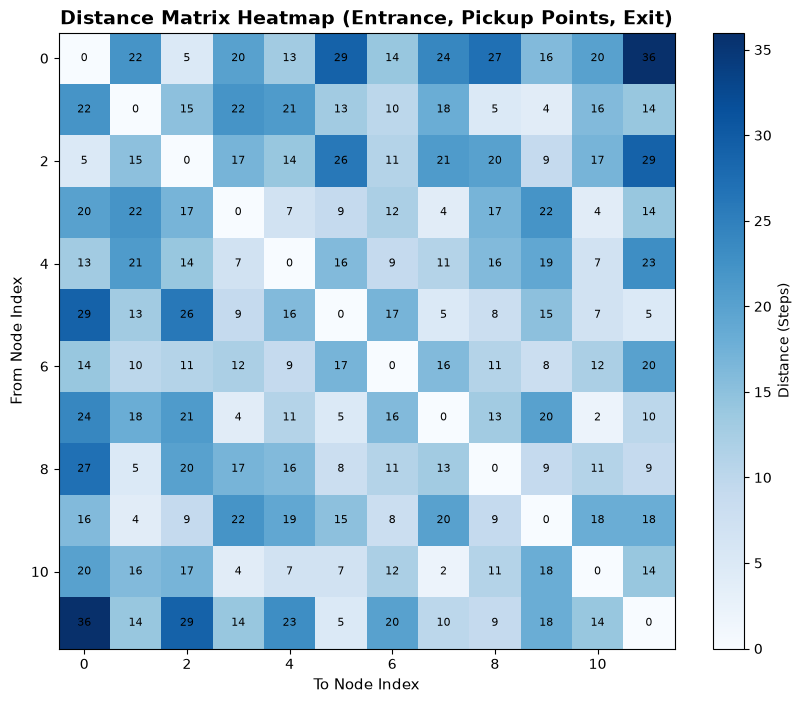

In [386]:
dist_matrix, valid_stands = build_distance_matrix(warehouse, entrance, exit_point, pickup_points)

plt.figure(figsize=(10, 8))
plt.imshow(dist_matrix, cmap="Blues", interpolation="nearest")
plt.colorbar(label="Distance (Steps)")

for i in range(dist_matrix.shape[0]):
    for j in range(dist_matrix.shape[1]):
        plt.text(j, i, f"{int(dist_matrix[i, j])}", ha="center", va="center", color="black", fontsize=8)

plt.title("Distance Matrix Heatmap (Entrance, Pickup Points, Exit)", fontsize=14, fontweight="bold")
plt.xlabel("To Node Index", fontsize=11)
plt.ylabel("From Node Index", fontsize=11)
plt.show()

## Multi-Start 2-Opt Algorithm (78 steps)

### 1. Route Cost Calculator

- คำนวณระยะทางรวมหรือต้นทุนของเส้นทาง (Route Cost) 

- นำค่าระยะทางใน Distance Matrix ของจุดแต่ละจุดเรียงตามลำดับการเดินมาบวกกันตั้งแต่จุดทางเข้าจนถึงจุดทางออก

In [387]:
def calculate_route_cost(route, dist_matrix):
    return sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1))

### 2. 2-Opt Optimization Algorithm

- อัลกอริทึมสำหรับปรับปรุงและจัดเรียงลำดับเส้นทาง (Local Search) 

- สลับเส้นเชื่อมเพื่อแก้ไขรอยตัดไขว้กันของเส้นทาง ช่วยให้ระยะทางเดินสั้นขึ้น

In [388]:
def two_opt(route, dist_matrix):
    best_route = route.copy()
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route) - 1):
                if j - i == 1: continue 
                
                current_dist = dist_matrix[best_route[i-1]][best_route[i]] + dist_matrix[best_route[j]][best_route[j+1]]
                new_dist = dist_matrix[best_route[i-1]][best_route[j]] + dist_matrix[best_route[i]][best_route[j+1]]
                
                if new_dist < current_dist:
                    best_route[i:j+1] = best_route[i:j+1][::-1]
                    improved = True
    return best_route

### 3. Multi-Start 2-Opt Optimization

- ฟังก์ชันหลักในการค้นหาเส้นทางที่ดีที่สุด

- สุ่มลำดับจุดเริ่มต้นหลายๆ รอบ (Multi-Start) แล้วนำไปผ่านอัลกอริทึม 2-Opt

- ป้องกันการติดค่าเหมาะสมที่สุดเฉพาะจุด (Local Minimum) 

- หาเส้นทางที่สั้นที่สุดทั่วทั้งแผนที่

In [389]:
def multi_start_2opt(dist_matrix, num_starts=200):
    num_nodes = len(dist_matrix)
    items = list(range(1, num_nodes - 1))
    global_best_route = None
    global_best_cost = float('inf')
    
    for _ in range(num_starts):
        random.shuffle(items)
        initial_route = [0] + items + [num_nodes - 1]
        
        optimized_route = two_opt(initial_route, dist_matrix)
        cost = calculate_route_cost(optimized_route, dist_matrix)
        
        if cost < global_best_cost:
            global_best_cost = cost
            global_best_route = optimized_route
            
    return global_best_route, global_best_cost

### 4. Warehouse Route Path Visualization (Multi-Start 2-Opt)

- ฟังก์ชันสร้างภาพกราฟิกแสดงผลแผนที่คลังสินค้า

In [390]:
def plot_warehouse_route(warehouse, entrance, exit_point, pickup_points, full_path, best_distance, stand_points=None):
    rows, cols = warehouse.shape
    colors = ["#EAF6FF", "#4A4A4A"]
    warehouse_cmap = ListedColormap(colors)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(warehouse, cmap=warehouse_cmap, origin="upper", interpolation="nearest")
    
    if full_path:
        path_r = [p[0] for p in full_path]
        path_c = [p[1] for p in full_path]
        plt.plot(path_c, path_r, color="#3498DB", linewidth=3, label="Walking Route", zorder=2)
        
    if stand_points:
        sp_r = [p[0] for p in stand_points]
        sp_c = [p[1] for p in stand_points]
        plt.scatter(sp_c, sp_r, color="#E67E22", s=100, marker='o', edgecolors="white", zorder=4)
    
    plt.scatter(entrance[1], entrance[0], color="#27AE60", s=220, edgecolors="black", zorder=3)
    plt.text(entrance[1], entrance[0], "IN", ha="center", va="center", color="white", fontweight="bold", fontsize=8, zorder=4)
    
    plt.scatter(exit_point[1], exit_point[0], color="#E74C3C", s=220, edgecolors="black", zorder=3)
    plt.text(exit_point[1], exit_point[0], "OUT", ha="center", va="center", color="white", fontweight="bold", fontsize=7, zorder=4)
    
    for index, point in enumerate(pickup_points, start=1):
        plt.scatter(point[1], point[0], color="#F1C40F", s=180, marker="s", edgecolors="black", zorder=3)
        plt.text(point[1], point[0], str(index), ha="center", va="center", fontweight="bold", color="black", zorder=4)

    plt.xticks(np.arange(-0.5, cols, 1), minor=True)
    plt.yticks(np.arange(-0.5, rows, 1), minor=True)
    plt.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    plt.title(f"Warehouse Optimal Routing (Multi-Start 2-Opt)", fontsize=14, fontweight="bold")
    
    legend_elements = [
        Patch(facecolor="#EAF6FF", edgecolor="black", label="Walkway (0)"),
        Patch(facecolor="#4A4A4A", edgecolor="black", label="Shelf (1)"),
        plt.Line2D([0], [0], color="#3498DB", linewidth=3, label="Walking Path"),
        plt.Line2D([0], [0], marker="o", color="w", label="Stand Point", markerfacecolor="#E67E22", markeredgecolor="white", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Entrance", markerfacecolor="#27AE60", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Exit", markerfacecolor="#E74C3C", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="s", color="w", label="Pickup Point", markerfacecolor="#F1C40F", markeredgecolor="black", markersize=10)
    ]
    
    plt.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=7)
    plt.show()

### 5. Continuous Path Stitching and Execution (Multi-Start 2-Opt)

- รวบรวมฟังก์ชันหลักมาประมวลผลเพื่อหาลำดับการหยิบสินค้าที่ดีที่สุดจาก Distance Matrix และ Multi-Start 2-Opt

- ใช้เทคนิค Path Stitching นำเส้นทางย่อยที่ได้จาก A* Search มาต่อกัน โดยตั้งเงื่อนไขบังคับให้เริ่มเดินต่อจากพิกัดก้าวสุดท้ายของโหนดก่อนหน้าเสมอ เพื่อแก้ปัญหาการลากเส้นทแยงทะลุชั้นวาง

- คำนวณระยะทางรวมให้ตรงกับจำนวนก้าวเดินจริง

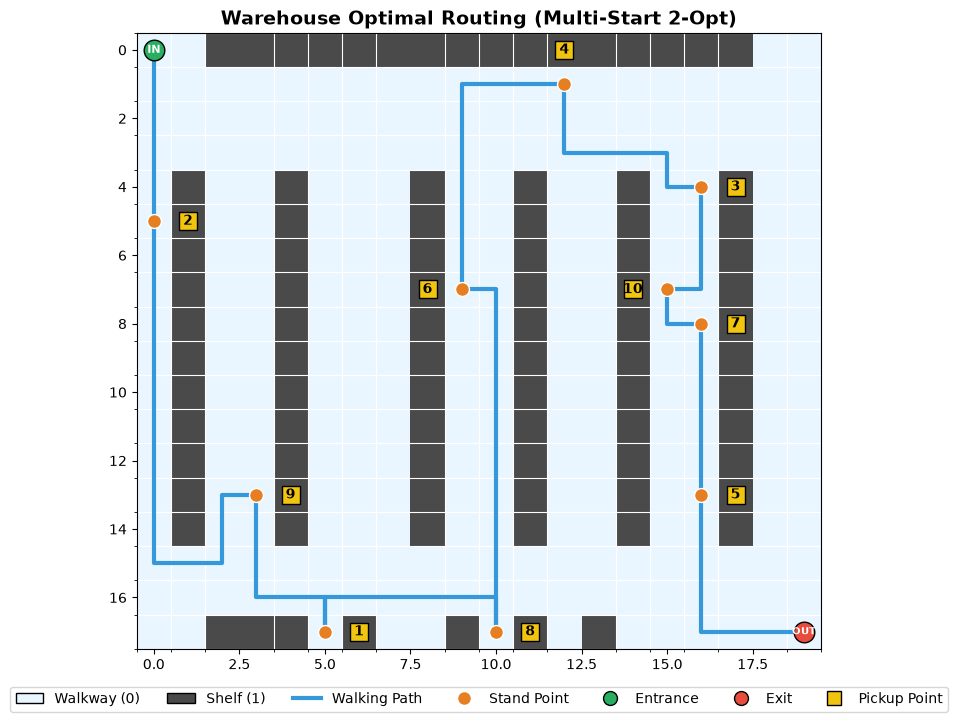

In [391]:
dist_matrix, valid_stands = build_distance_matrix(warehouse, entrance, exit_point, pickup_points)
best_sequence, best_distance = multi_start_2opt(dist_matrix, num_starts=200)

full_path = []
stand_points = [] 

for i in range(len(best_sequence) - 1):
    start_node = best_sequence[i]
    target_node = best_sequence[i+1]
    
    if i == 0:
        starts = valid_stands[start_node]
    else:
        starts = [full_path[-1]]
        
    targets = valid_stands[target_node]
    _, path_segment = a_star_search(warehouse, starts, targets)
    
    if i == 0:
        full_path.extend(path_segment)
    else:
        full_path.extend(path_segment[1:]) 
        
    if i < len(best_sequence) - 2:
        stand_points.append(path_segment[-1])

real_distance = len(full_path) - 1

plot_warehouse_route(warehouse, entrance, exit_point, pickup_points, full_path, real_distance, stand_points)

### 6. Print Minimum Distance Result (Multi-Start 2-Opt)

- แสดงผลลัพธ์ตัวเลขระยะทางที่สั้นที่สุด (MinDistance) ของวิธี Multi-Start 2-Opt ในหน่วยก้าวเดินจริง (Steps)

In [392]:
print(f"MinDistance (Multi-Start 2-Opt) = {real_distance} steps")

MinDistance (Multi-Start 2-Opt) = 78 steps


## Stand-Aware Multi-Start 2-Opt (72 steps)

- กำหนดค่าคงที่ของโจทย์ Grid-State (ทางเข้า ทางออก ทิศการเดิน 4 ทิศ จำนวนสินค้า) ไว้ที่เดียว เพื่อให้ทุกฟังก์ชันใช้ค่าชุดเดียวกัน และแก้กฎของโจทย์ได้จากจุดเดียว

In [393]:
ENTRANCE = entrance
EXIT = exit_point
MOVES = ((-1, 0), (1, 0), (0, -1), (0, 1))
PICKUP_COUNT = n

### 1. Pickup Masks Generator

- ฟังก์ชันสร้างบิตแมสก์ของช่องทางเดิน

- ตรวจว่าแต่ละช่องทางเดินอยู่ติดสินค้าชิ้นไหนบ้าง แล้วเก็บเป็นเลขบิต

- ใช้ดูว่าเส้นทางจริงหยิบสินค้าชิ้นไหนไปบ้าง เพื่อสร้างลำดับการหยิบ

In [394]:
def pickup_masks(pickups, warehouse_grid):
    masks = {}
    for row, col in zip(*np.where(warehouse_grid == 0)):
        masks[row, col] = sum(
            1 << index
            for index, (pickup_row, pickup_col) in enumerate(pickups)
            if abs(row - pickup_row) + abs(col - pickup_col) == 1
        )
    return masks

### 2. Grid Distance Table

- ตารางระยะทางจริงระหว่างทุกคู่ช่องทางเดิน

- ใช้ BFS เดินจากทุกช่องไปทุกช่อง แล้วเก็บจำนวนก้าวที่สั้นที่สุด

- คิดระดับช่องทางเดิน เพื่อรู้ระยะของจุดยืนแต่ละจุด

In [395]:
def grid_distance_table(warehouse_grid):
    from collections import deque
    rows, cols = warehouse_grid.shape
    walk = [(r, c) for r in range(rows) for c in range(cols) if warehouse_grid[r, c] == 0]
    table = {}
    for src in walk:
        dist = {src: 0}
        queue = deque([src])
        while queue:
            r, c = queue.popleft()
            for dr, dc in MOVES:
                nxt = (r + dr, c + dc)
                if (0 <= nxt[0] < rows and 0 <= nxt[1] < cols
                        and warehouse_grid[nxt] == 0 and nxt not in dist):
                    dist[nxt] = dist[(r, c)] + 1
                    queue.append(nxt)
        table[src] = dist
    return table

### 3. Best Stand Position Selector

- ประเมินต้นทุนของลำดับการเดิน

- ใช้ DP เลือกจุดยืนหยิบของแต่ละชิ้นให้รวมแล้วเดินสั้นที่สุด คืนระยะทางจริงและจุดยืนที่เลือก

- เป็นหัวใจของ "Stand-Aware" ทำให้ต้นทุนตรงกับก้าวเดินจริง

In [396]:
def best_stand_route(order, stand_lists, cell_dist):
    layer = {s: (0, None) for s in stand_lists[order[0]]}
    history = [layer]
    for node in order[1:]:
        new_layer = {}
        for cell in stand_lists[node]:
            best_prev, best_cost = None, float('inf')
            for prev, (cost, _) in layer.items():
                total = cost + cell_dist[prev][cell]
                if total < best_cost:
                    best_cost, best_prev = total, prev
            new_layer[cell] = (best_cost, best_prev)
        history.append(new_layer)
        layer = new_layer
    end_cell = min(layer, key=lambda c: layer[c][0])
    total_cost = layer[end_cell][0]
    chosen = [end_cell]
    for layer in reversed(history[1:]):
        chosen.append(layer[chosen[-1]][1])
    return total_cost, list(reversed(chosen))

### 4. Stand-Aware 2-Opt and Or-Opt

- Local Search ที่ปรับปรุงลำดับสินค้า

- ลองกลับช่วงลำดับ (2-Opt) และย้ายสินค้าทีละชิ้น (Or-Opt) เก็บการเปลี่ยนที่ทำให้ระยะจริงสั้นลง วนจนไม่มีอะไรดีขึ้น

- วัดผลด้วยระยะเดินจริงจากข้อ 3 และเพิ่ม Or-Opt

In [397]:
def two_opt_true_cost(route, cost_fn):
    best = list(route)
    best_cost = cost_fn(best)
    improved = True
    while improved:
        improved = False
        size = len(best)
        for i in range(1, size - 2):
            for j in range(i + 1, size - 1):
                cand = best[:i] + best[i:j + 1][::-1] + best[j + 1:]
                c = cost_fn(cand)
                if c < best_cost:
                    best, best_cost, improved = cand, c, True
        for i in range(1, size - 1):
            for j in range(1, size - 1):
                if i == j: continue
                cand = best[:i] + best[i + 1:]
                cand.insert(j, best[i])
                c = cost_fn(cand)
                if c < best_cost:
                    best, best_cost, improved = cand, c, True
    return best, best_cost

### 5.Improved Multi-Start 2-Opt Optimization

- สุ่มลำดับเริ่มต้นหลายรอบ ผ่านข้อ 4 ทุกรอบ แล้วเก็บลำดับที่ระยะสั้นที่สุด

- ลดโอกาสติด Local Minimum

In [398]:
def multi_start_2opt_v2(stand_lists, cell_dist, num_starts=200, seed=42):
    rng = random.Random(seed)
    num_nodes = len(stand_lists)
    items = list(range(1, num_nodes - 1))
    cost_fn = lambda r: best_stand_route(r, stand_lists, cell_dist)[0]
    best_route, best_cost = None, float('inf')
    for _ in range(num_starts):
        rng.shuffle(items)
        route, cost = two_opt_true_cost([0] + items + [num_nodes - 1], cost_fn)
        if cost < best_cost:
            best_route, best_cost = route, cost
    return best_route, best_cost

### 6. Stand-Based Path Stitching

- นำจุดยืนที่ DP เลือกมาเชื่อมกันด้วย A* ได้เส้นทางต่อเนื่องบนทางเดินเท่านั้น

In [399]:
def stitch_from_stands(chosen_stands, warehouse_grid):
    path = [chosen_stands[0]]
    for a, b in zip(chosen_stands, chosen_stands[1:]):
        _, seg = a_star_search(warehouse_grid, [a], [b])
        path.extend(seg[1:])
    return path

### 7. Pickup Order Extractor

- ตัวอ่านลำดับการหยิบสินค้า

- เดินตามเส้นทางจริง จดสินค้าตามที่ผ่านช่องที่ติดสินค้า (รวมชิ้นที่หยิบระหว่างทาง)

In [400]:
def pickup_order_from_path(path, masks, n_items):
    mask, order = masks[path[0]], []
    for index in range(n_items):
        if mask & (1 << index): order.append(index + 1)
    for cell in path[1:]:
        gained = masks[cell] & ~mask
        for index in range(n_items):
            if gained & (1 << index): order.append(index + 1)
        mask |= masks[cell]
    return order

### 8. Execution

- ประมวลผลและวาดภาพแผนผังเส้นทางเดินจริงบนตารางกริดคลังสินค้า

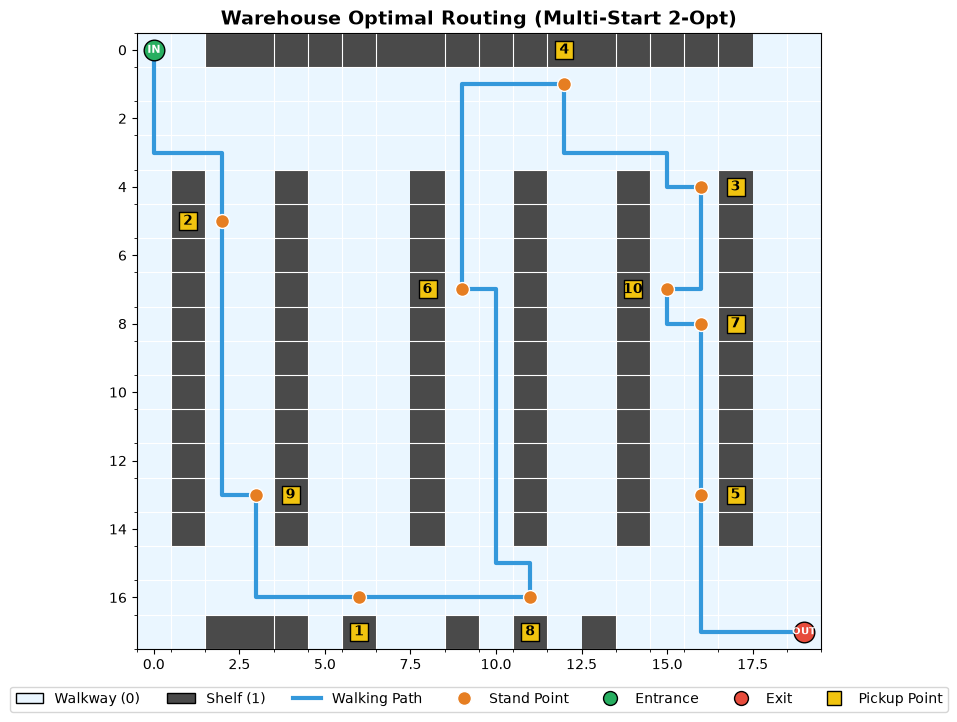

In [401]:
cell_dist = grid_distance_table(warehouse)
stand_cells = [[entrance]] + [get_valid_stand_positions(warehouse, p) for p in pickup_points] + [[exit_point]]

ms_route, ms_cost = multi_start_2opt_v2(stand_cells, cell_dist, num_starts=200, seed=42)
_, chosen_stands = best_stand_route(ms_route, stand_cells, cell_dist)

ms_full_path = stitch_from_stands(chosen_stands, warehouse)
ms_visit_order = pickup_order_from_path(ms_full_path, pickup_masks(pickup_points, warehouse), n)
ms_real_distance = len(ms_full_path) - 1

plot_warehouse_route(warehouse, entrance, exit_point, pickup_points, ms_full_path, ms_real_distance, stand_points=chosen_stands[1:-1])

### 9. Print Minimum Distance Result (Stand-Aware Multi-Start 2-Opt)

- แสดงผลลัพธ์ตัวเลขระยะทางรวมที่สั้นที่สุดและลำดับการหยิบสินค้าของวิธี Stand-Aware Multi-Start 2-Opt

In [402]:
print(f"MinDistance (Stand-Aware Multi-Start 2-Opt) = {ms_real_distance} steps")
print(f"Optimal Pickup Order: {ms_visit_order}")

MinDistance (Stand-Aware Multi-Start 2-Opt) = 72 steps
Optimal Pickup Order: [2, 9, 1, 8, 6, 4, 3, 10, 7, 5]


## Q-Learning Algorithm for TSP Routing (100 steps)

### 1. Q-Learning Route Function

- ฟังก์ชันสำหรับใช้อัลกอริทึม Q-Learning ในการแก้ปัญหาการจัดลำดับการเดินทาง (TSP)

- ให้พนักงานเรียนรู้ผ่านการเลือกแอคชันและรับรางวัล เพื่อหาลำดับการแวะหยิบสินค้าที่ดีที่สุด

In [403]:
def q_learning_route(dist_matrix, episodes=10000, alpha=0.15, gamma=1.0,
                     epsilon_start=1.0, epsilon_end=0.02, seed=42):
    rng = np.random.default_rng(seed)
    n_nodes = len(dist_matrix)
    pickup_nodes = list(range(1, n_nodes - 1))
    full_mask = (1 << len(pickup_nodes)) - 1
    q, episode_costs = {}, []
    
    def q_values(state):
        if state not in q:
            q[state] = np.zeros(len(pickup_nodes), dtype=float)
        return q[state]
        
    for episode in range(episodes):
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * (1 - episode / episodes)
        current, mask, total_cost = 0, 0, 0.0
        while mask != full_mask:
            state = (current, mask)
            available = [a for a in range(len(pickup_nodes)) if not (mask & (1 << a))]
            values = q_values(state)
            if rng.random() < epsilon:
                action = int(rng.choice(available))
            else:
                best = np.max(values[available])
                action = int(rng.choice([a for a in available if values[a] == best]))
            next_node = pickup_nodes[action]
            step_cost = dist_matrix[current, next_node]
            next_mask = mask | (1 << action)
            reward = -step_cost
            if next_mask == full_mask:
                reward -= dist_matrix[next_node, n_nodes - 1]
                future = 0.0
            else:
                next_available = [a for a in range(len(pickup_nodes)) if not (next_mask & (1 << a))]
                future = np.max(q_values((next_node, next_mask))[next_available])
            values[action] += alpha * (reward + gamma * future - values[action])
            total_cost += step_cost
            current, mask = next_node, next_mask
        episode_costs.append(total_cost + dist_matrix[current, n_nodes - 1])
        
    current, mask, route = 0, 0, [0]
    while mask != full_mask:
        available = [a for a in range(len(pickup_nodes)) if not (mask & (1 << a))]
        values = q_values((current, mask))
        action = int(available[np.argmax(values[available])])
        current = pickup_nodes[action]
        mask |= 1 << action
        route.append(current)
    route.append(n_nodes - 1)
    return route, calculate_route_cost(route, dist_matrix), episode_costs

### 2. Stitch Route Function

- ฟังก์ชันสำหรับนำลำดับโหนด (Node Sequence) ที่จัดเรียงแล้ว มาเชื่อมต่อเส้นทางเดินย่อยระหว่างจุดต่างๆ เข้าด้วยกัน

- ใช้ A* Search เพื่อสร้างเส้นทางเดินต่อเนื่องจริงบนกริดแผนที่คลังสินค้า

In [404]:
def stitch_route(route, warehouse, valid_stands):
    path, stands = [], []
    for i in range(len(route) - 1):
        starts = valid_stands[route[i]] if i == 0 else [path[-1]]
        _, segment = a_star_search(warehouse, starts, valid_stands[route[i + 1]])
        path.extend(segment if i == 0 else segment[1:])
        if i < len(route) - 2:
            stands.append(segment[-1])
    return path, stands, len(path) - 1

### 3. Warehouse Route Path Visualization (Q-Learning)

In [405]:
def plot_q_learning_route(warehouse, entrance, exit_point, pickup_points, full_path, best_distance, stand_points=None):
    rows, cols = warehouse.shape
    colors = ["#EAF6FF", "#4A4A4A"]
    warehouse_cmap = ListedColormap(colors)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(warehouse, cmap=warehouse_cmap, origin="upper", interpolation="nearest")
    
    if full_path:
        path_r = [p[0] for p in full_path]
        path_c = [p[1] for p in full_path]
        plt.plot(path_c, path_r, color="#3498DB", linewidth=3, label="Walking Route", zorder=2)
        
    if stand_points:
        sp_r = [p[0] for p in stand_points]
        sp_c = [p[1] for p in stand_points]
        plt.scatter(sp_c, sp_r, color="#E67E22", s=100, marker='o', edgecolors="white", zorder=4)
    
    plt.scatter(entrance[1], entrance[0], color="#27AE60", s=220, edgecolors="black", zorder=3)
    plt.text(entrance[1], entrance[0], "IN", ha="center", va="center", color="white", fontweight="bold", fontsize=8, zorder=4)
    
    plt.scatter(exit_point[1], exit_point[0], color="#E74C3C", s=220, edgecolors="black", zorder=3)
    plt.text(exit_point[1], exit_point[0], "OUT", ha="center", va="center", color="white", fontweight="bold", fontsize=7, zorder=4)
    
    for index, point in enumerate(pickup_points, start=1):
        plt.scatter(point[1], point[0], color="#F1C40F", s=180, marker="s", edgecolors="black", zorder=3)
        plt.text(point[1], point[0], str(index), ha="center", va="center", fontweight="bold", color="black", zorder=4)

    plt.xticks(np.arange(-0.5, cols, 1), minor=True)
    plt.yticks(np.arange(-0.5, rows, 1), minor=True)
    plt.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    plt.title("Warehouse Optimal Routing (Q-Learning)", fontsize=14, fontweight="bold")
    
    legend_elements = [
        Patch(facecolor="#EAF6FF", edgecolor="black", label="Walkway (0)"),
        Patch(facecolor="#4A4A4A", edgecolor="black", label="Shelf (1)"),
        plt.Line2D([0], [0], color="#3498DB", linewidth=3, label="Walking Path"),
        plt.Line2D([0], [0], marker="o", color="w", label="Stand Point", markerfacecolor="#E67E22", markeredgecolor="white", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Entrance", markerfacecolor="#27AE60", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Exit", markerfacecolor="#E74C3C", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="s", color="w", label="Pickup Point", markerfacecolor="#F1C40F", markeredgecolor="black", markersize=10)
    ]
    
    plt.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=7)
    plt.show()

### 4. Continuous Path Stitching and Execution (Q-Learning)

- เชื่อมต่อเส้นทางเดินจริงทั้งหมดของ Q-Learning

- แปลงข้อมูลออกมาเป็นภาพแผนผังเส้นทางเดินภายในคลังสินค้า

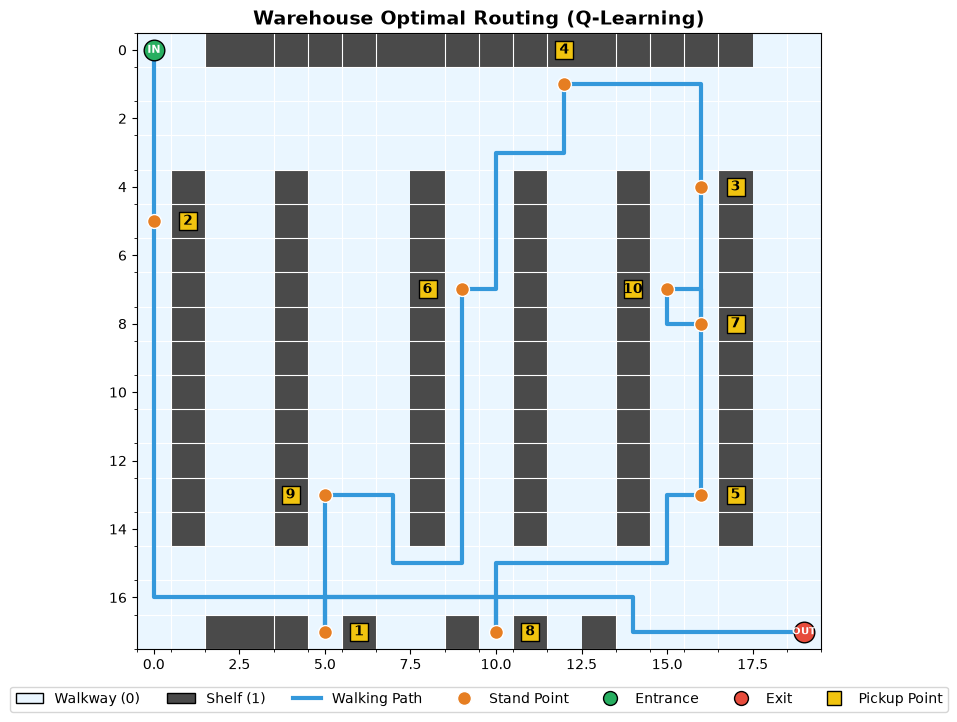

In [406]:
q_route, q_matrix_cost, q_episode_costs = q_learning_route(
    dist_matrix, 
    episodes=10000, 
    alpha=0.15, 
    gamma=1.0, 
    epsilon_start=1.0, 
    epsilon_end=0.02, 
    seed=42
)

q_full_path = []
q_stand_points = [] 

for i in range(len(q_route) - 1):
    start_node = q_route[i]
    target_node = q_route[i+1]
    
    if i == 0:
        starts = valid_stands[start_node]
    else:
        starts = [q_full_path[-1]]
        
    targets = valid_stands[target_node]
    _, path_segment = a_star_search(warehouse, starts, targets)
    
    if path_segment:
        if i == 0:
            q_full_path.extend(path_segment)
        else:
            q_full_path.extend(path_segment[1:]) 
            
        if i < len(q_route) - 2:
            q_stand_points.append(path_segment[-1])

q_real_distance = len(q_full_path) - 1 if q_full_path else 0

plot_q_learning_route(
    warehouse, 
    entrance, 
    exit_point, 
    pickup_points, 
    q_full_path, 
    q_real_distance, 
    q_stand_points
)

### 5. Print Minimum Distance Result (Q-Learning)

- แสดงผลลัพธ์ตัวเลขระยะทางรวมที่สั้นที่สุด (MinDistance) ของวิธี Q-Learning ในหน่วยก้าวเดินจริง (Steps)

In [407]:
print(f"MinDistance (Q-Learning) = {q_real_distance} steps")

MinDistance (Q-Learning) = 100 steps


## Demonstration-Assisted Grid-State Q-Learning (72 Steps)

### 1. Pickup Masks Generator

- สร้างบิตแมสก์ (Bit Mask) สำหรับแต่ละช่องทางเดินที่อยู่ติดกับจุดหยิบสินค้า

- ช่วยให้ระบบจดจำสถานะได้ว่าเมื่อพนักงานเดินมาถึงพิกัดนี้ จะถือว่าหยิบสินค้าชิ้นไหนไปแล้วบ้าง

In [408]:
def pickup_masks(pickups, warehouse_grid):
    masks = {}
    for row, col in zip(*np.where(warehouse_grid == 0)):
        masks[row, col] = sum(
            1 << index
            for index, (pickup_row, pickup_col) in enumerate(pickups)
            if abs(row - pickup_row) + abs(col - pickup_col) == 1
        )
    return masks

### 2. Optimal Demonstration Path Planner

- ค้นหาเส้นทางที่สั้นที่สุดบนตารางกริด (Shortest Feasible Trajectory) ที่เก็บสินค้าครบทุกจุดและเดินออกทางออกสำเร็จ

- ใช้เป็นข้อมูล "เส้นทางสาธิต (Demonstration)" เพื่อป้อนเป็นแนวทางให้เอเจนต์เรียนรู้แทนการสุ่มเดิน

In [409]:
def optimal_demonstration(masks, full_mask, entrance_pos, exit_pos, warehouse_grid):
    rows, cols = warehouse_grid.shape
    cells = rows * cols
    state_count = (full_mask + 1) * cells
    parent = np.full(state_count, -1, dtype=np.int32)
    actions = np.full(state_count, -1, dtype=np.int8)
    queue = np.empty(state_count, dtype=np.int32)

    def state_id(row, col, mask):
        return mask * cells + row * cols + col

    def unpack(encoded):
        mask, cell = divmod(int(encoded), cells)
        return cell // cols, cell % cols, mask

    start = state_id(*entrance_pos, masks[entrance_pos])
    parent[start] = start
    queue[0] = start
    head, tail = 0, 1
    goal = None

    while head < tail:
        current = queue[head]
        head += 1
        row, col, mask = unpack(current)
        if (row, col) == exit_pos and mask == full_mask:
            goal = current
            break
        for action, (d_row, d_col) in enumerate(MOVES):
            next_row, next_col = row + d_row, col + d_col
            if not (0 <= next_row < rows and 0 <= next_col < cols):
                continue
            if warehouse_grid[next_row, next_col] != 0:
                continue
            next_state = state_id(
                next_row, next_col, mask | masks[next_row, next_col]
            )
            if parent[next_state] == -1:
                parent[next_state] = current
                actions[next_state] = action
                queue[tail] = next_state
                tail += 1

    if goal is None:
        raise RuntimeError("No feasible route visits every pickup and reaches the exit.")

    transitions = []
    while goal != start:
        previous = parent[goal]
        transitions.append((unpack(previous), int(actions[goal]), unpack(goal)))
        goal = previous
    return list(reversed(transitions))

### 3. Q-Learning Training from Demonstration

- ฝึกสอนโมเดล Q-Learning โดยทบทวนซ้ำจากเส้นทางสาธิตที่เตรียมไว้

- อัปเดตค่า Q-Value ของแต่ละแอคชันเพื่อผลักดันให้เอเจนต์เลือกเดินเส้นทางที่สั้นที่สุดและได้รับรางวัลสูงสุด

In [410]:
def train_from_demonstration(transitions, full_mask, epochs=5000, alpha=0.20, gamma=1.0):
    q_values = {}
    def values(state):
        return q_values.setdefault(state, np.zeros(4, dtype=float))

    for _ in range(epochs):
        for state, action, next_state in transitions:
            finished = (next_state[:2] == exit_point and next_state[2] == full_mask)
            reward = 100.0 if finished else -1.0
            future = 0.0 if finished else float(np.max(values(next_state)))
            current = values(state)
            current[action] += alpha * (reward + gamma * future - current[action])
    return q_values

### 4. Greedy Policy Rollout

- จำลองการเดินจริงของพนักงานตามนโยบาย (Policy) ที่ฝึกสอนเสร็จแล้ว

- พาพนักงานเดินเก็บสินค้าครบ 10 จุดและเดินออกทางออก พร้อมบันทึกพิกัดเส้นทางเดินจริง

In [411]:
def greedy_rollout(q_values, masks, full_mask, max_steps=200):
    state = (*entrance, masks[entrance])
    path = [entrance]
    visited_pickups = []
    for _ in range(max_steps):
        if state[:2] == exit_point and state[2] == full_mask:
            return path, visited_pickups
        action = int(np.argmax(q_values[state]))
        d_row, d_col = MOVES[action]
        next_row, next_col = state[0] + d_row, state[1] + d_col
        if not (0 <= next_row < warehouse.shape[0] and 0 <= next_col < warehouse.shape[1]):
            raise RuntimeError("Policy selected an out-of-bounds move.")
        if warehouse[next_row, next_col] != 0:
            raise RuntimeError("Policy selected a shelf cell.")
        next_mask = state[2] | masks[next_row, next_col]
        gained = next_mask & ~state[2]
        for index in range(n):
            if gained & (1 << index):
                visited_pickups.append(index + 1)
        state = next_row, next_col, next_mask
        path.append((next_row, next_col))
    raise RuntimeError("Policy did not complete within the step budget.")

### 5. Execution and Route Visualization

- ประมวลผลและวาดภาพแผนผังเส้นทางเดินจริงบนตารางกริดคลังสินค้า

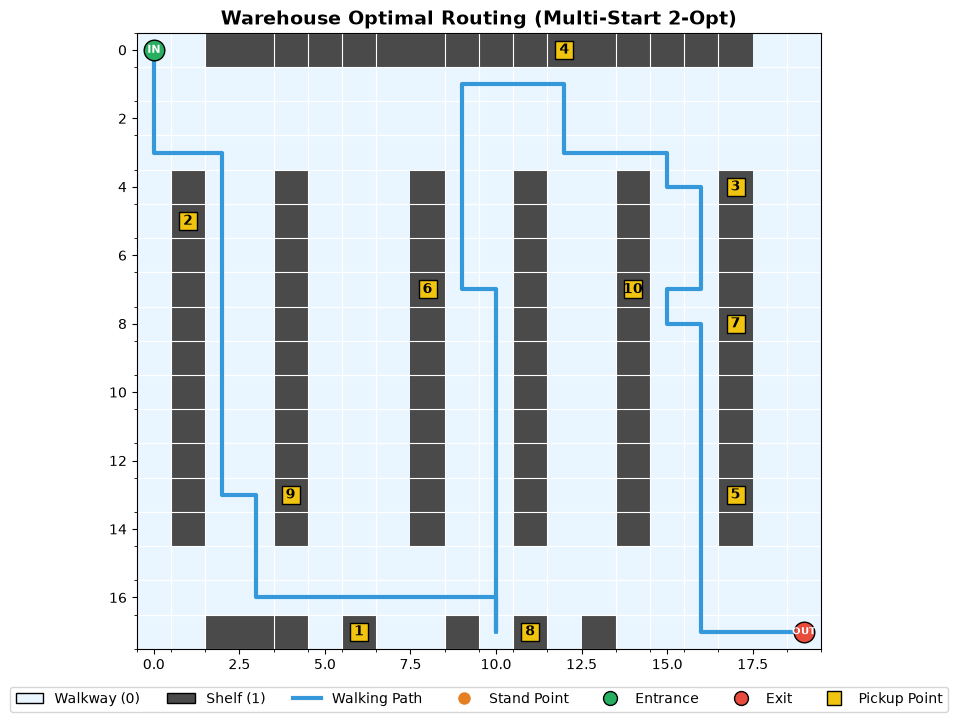

In [412]:
masks_dict = pickup_masks(pickup_points, warehouse)
full_mask_val = (1 << n) - 1

demo_transitions = optimal_demonstration(masks_dict, full_mask_val, entrance, exit_point, warehouse)
q_values_trained = train_from_demonstration(demo_transitions, full_mask_val, epochs=5000, alpha=0.20, gamma=1.0)
q_full_path, q_visit_order = greedy_rollout(q_values_trained, masks_dict, full_mask_val)

q_real_distance = len(q_full_path) - 1

plot_warehouse_route(warehouse, entrance, exit_point, pickup_points, q_full_path, q_real_distance, stand_points=None)

### 6. Print Minimum Distance Result (Grid-State Q-Learning)

- แสดงผลลัพธ์ตัวเลขระยะทางรวมที่สั้นที่สุดและลำดับการหยิบสินค้าของวิธี Grid-State Q-Learning

In [413]:
print(f"MinDistance (Grid-State Q-Learning) = {q_real_distance} steps")
print(f"Optimal Pickup Order: {q_visit_order}")

MinDistance (Grid-State Q-Learning) = 72 steps
Optimal Pickup Order: [2, 9, 1, 8, 6, 4, 3, 10, 7, 5]


## Performance Comparison Table

- ตารางเปรียบเทียบ (Performance Table)

In [414]:
# --- 1) Multi-Start 2-Opt (เดิม) ---
random.seed(42)
start = time.perf_counter()
two_opt_route, two_opt_matrix_cost = multi_start_2opt(dist_matrix, num_starts=200)
two_opt_runtime = time.perf_counter() - start
two_opt_full_path, two_opt_stands, two_opt_real_distance = stitch_route(two_opt_route, warehouse, valid_stands)

# --- 2) Q-Learning (เดิม) ---
start = time.perf_counter()
q_route, q_matrix_cost, q_episode_costs = q_learning_route(dist_matrix, episodes=10000, seed=42)
q_runtime = time.perf_counter() - start
q_full_path, q_stand_points, q_real_distance = stitch_route(q_route, warehouse, valid_stands)

# --- 3) Grid-State Q-Learning ---
start = time.perf_counter()
gs_masks = pickup_masks(pickup_points, warehouse)
gs_full_mask = (1 << n) - 1
gs_transitions = optimal_demonstration(gs_masks, gs_full_mask, entrance, exit_point, warehouse)
gs_q_values = train_from_demonstration(gs_transitions, gs_full_mask, epochs=5000, alpha=0.20, gamma=1.0)
gs_full_path, gs_visit_order = greedy_rollout(gs_q_values, gs_masks, gs_full_mask)
gs_runtime = time.perf_counter() - start
gs_real_distance = len(gs_full_path) - 1

# --- 4) Stand-Aware Multi-Start 2-Opt ---
start = time.perf_counter()
sa_cell_dist = grid_distance_table(warehouse)
sa_stand_cells = [[entrance]] + [get_valid_stand_positions(warehouse, p) for p in pickup_points] + [[exit_point]]
sa_route, sa_cost = multi_start_2opt_v2(sa_stand_cells, sa_cell_dist, num_starts=200, seed=42)
_, sa_chosen_stands = best_stand_route(sa_route, sa_stand_cells, sa_cell_dist)
sa_full_path = stitch_from_stands(sa_chosen_stands, warehouse)
sa_runtime = time.perf_counter() - start
sa_real_distance = len(sa_full_path) - 1

# --- รวมผลลัพธ์ทั้ง 4 วิธี ---
results = [
    {"name": "Multi-Start 2-Opt",             "distance": two_opt_real_distance, "runtime": two_opt_runtime,
     "matrix": f"{two_opt_matrix_cost:.0f}",   "order": pickup_order_from_path(two_opt_full_path, gs_masks, n)},
    {"name": "Q-Learning",                    "distance": q_real_distance,       "runtime": q_runtime,
     "matrix": f"{q_matrix_cost:.0f}",         "order": pickup_order_from_path(q_full_path, gs_masks, n)},
    {"name": "Grid-State Q-Learning",         "distance": gs_real_distance,      "runtime": gs_runtime,
     "matrix": f"{gs_real_distance}",                            "order": gs_visit_order},
    {"name": "Stand-Aware Multi-Start 2-Opt", "distance": sa_real_distance,      "runtime": sa_runtime,
     "matrix": f"{sa_cost:.0f}",                            "order": pickup_order_from_path(sa_full_path, gs_masks, n)},
]
best_real_distance = min(r["distance"] for r in results)

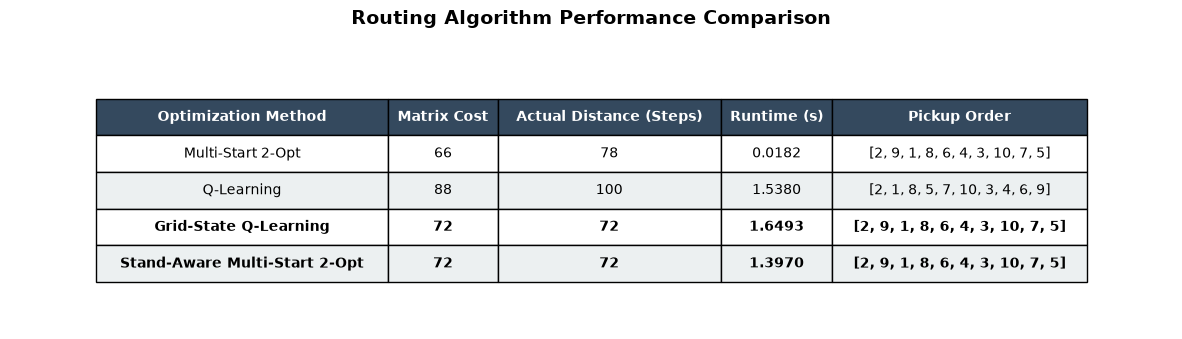

In [415]:
table_data = [
    [r["name"], f"{r['matrix']}", f"{r['distance']}", f"{r['runtime']:.4f}", str(r["order"])]
    for r in results
]
columns = ["Optimization Method", "Matrix Cost", "Actual Distance (Steps)", "Runtime (s)", "Pickup Order"]

fig, ax = plt.subplots(figsize=(15, 3.6))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(5)))
table.scale(1.0, 2.2)

for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_facecolor('#34495E')
        cell.set_text_props(weight='bold', color='white')
    else:
        cell.set_facecolor('#ECF0F1' if key[0] % 2 == 0 else 'white')
        if results[key[0] - 1]["distance"] == best_real_distance:
            cell.set_text_props(weight='bold')

plt.title("Routing Algorithm Performance Comparison", fontsize=14, fontweight='bold', pad=20)
plt.show()

## Performance Metrics & Learning Curve

- กราฟการเรียนรู้ (Learning Curve) และแผนภูมิแท่งเปรียบเทียบระยะทางและเวลา (Runtime)

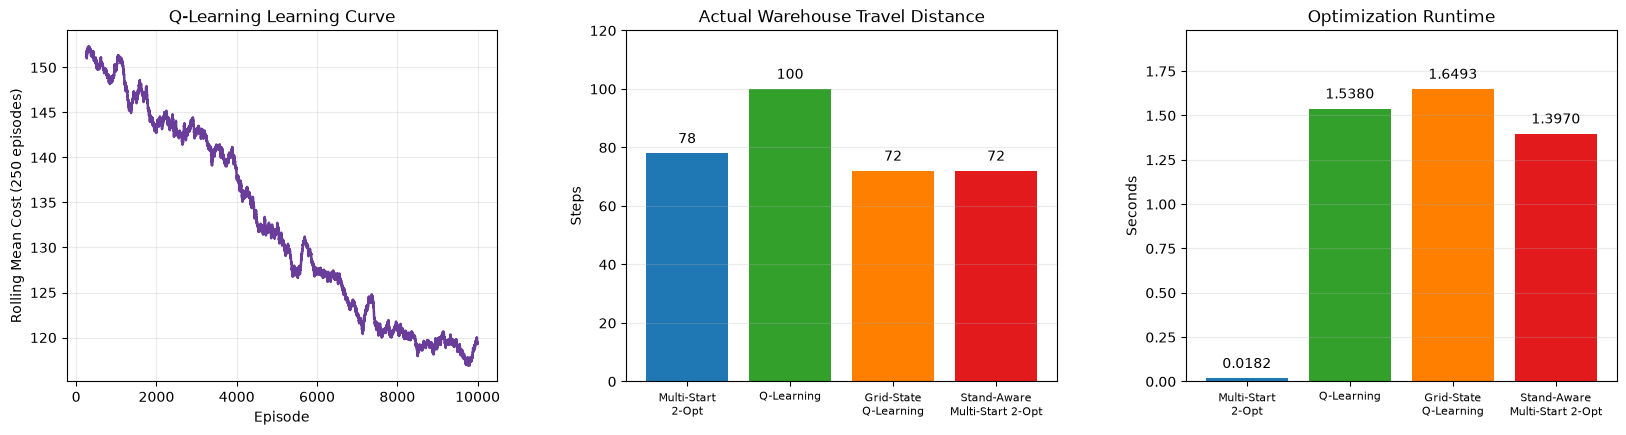

In [416]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.4))
window = 250
rolling_cost = np.convolve(q_episode_costs, np.ones(window) / window, mode='valid')

axes[0].plot(np.arange(window, len(q_episode_costs) + 1), rolling_cost, color='#6a3d9a', lw=1.8)
axes[0].set(title='Q-Learning Learning Curve', xlabel='Episode', ylabel=f'Rolling Mean Cost ({window} episodes)')
axes[0].grid(alpha=0.25)

methods = [r["name"] for r in results]
labels = [m.replace(" ", "\n", 1) if len(m) > 14 else m for m in methods]
colors = ['#1f78b4', '#33a02c', '#ff7f00', '#e31a1c']

bars1 = axes[1].bar(labels, [r["distance"] for r in results], color=colors)
axes[1].set(title='Actual Warehouse Travel Distance', ylabel='Steps')
axes[1].set_ylim(0, max(r["distance"] for r in results) * 1.2)
axes[1].bar_label(bars1, fmt='%.0f', padding=5)
axes[1].grid(axis='y', alpha=0.25)
axes[1].tick_params(axis='x', labelsize=8)

bars2 = axes[2].bar(labels, [r["runtime"] for r in results], color=colors)
axes[2].set(title='Optimization Runtime', ylabel='Seconds')
axes[2].set_ylim(0, max(r["runtime"] for r in results) * 1.2)
axes[2].bar_label(bars2, fmt='%.4f', padding=5)
axes[2].grid(axis='y', alpha=0.25)
axes[2].tick_params(axis='x', labelsize=8)

plt.subplots_adjust(wspace=0.3, top=0.85, bottom=0.2)
plt.show()

## Performance Difference Summary

- ตารางสรุปส่วนต่างประสิทธิภาพ

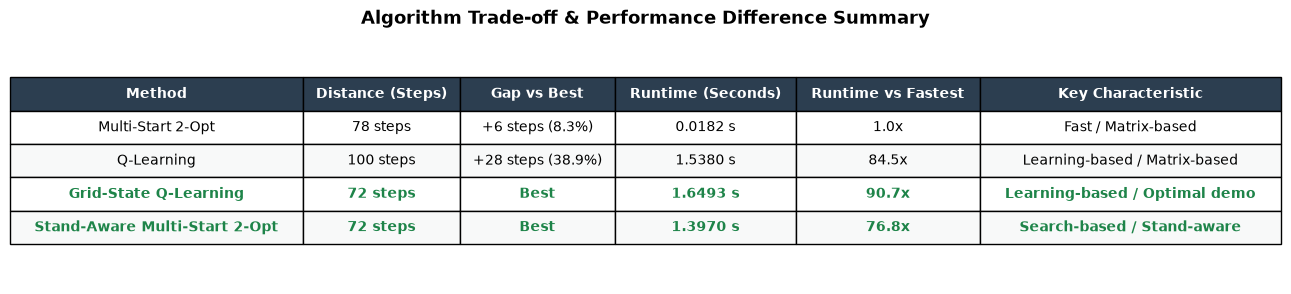

In [417]:
fastest_runtime = min(r["runtime"] for r in results)
characteristics = {
    "Multi-Start 2-Opt": "Fast / Matrix-based",
    "Q-Learning": "Learning-based / Matrix-based",
    "Grid-State Q-Learning": "Learning-based / Optimal demo",
    "Stand-Aware Multi-Start 2-Opt": "Search-based / Stand-aware",
}

summary_table_data = []
for r in results:
    gap = 100 * (r["distance"] - best_real_distance) / best_real_distance
    summary_table_data.append([
        r["name"],
        f"{r['distance']} steps",
        f"+{r['distance'] - best_real_distance} steps ({gap:.1f}%)" if gap > 0 else "Best",
        f"{r['runtime']:.4f} s",
        f"{r['runtime'] / fastest_runtime:.1f}x",
        characteristics[r["name"]],
    ])
summary_columns = ["Method", "Distance (Steps)", "Gap vs Best", "Runtime (Seconds)", "Runtime vs Fastest", "Key Characteristic"]

fig, ax = plt.subplots(figsize=(15, 3.2))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_table_data, colLabels=summary_columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(6)))
table.scale(1.0, 2.0)

for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(weight='bold', color='white')
    else:
        cell.set_facecolor('#F8F9F9' if key[0] % 2 == 0 else 'white')
        if results[key[0] - 1]["distance"] == best_real_distance:
            cell.set_text_props(weight='bold', color='#1E8449')

plt.title("Algorithm Trade-off & Performance Difference Summary", fontsize=13, fontweight='bold', pad=10)
plt.show()

## สรุปผลลัพธ์

1. ลำดับการหยิบสินค้า (Pickup Node Sequence)

    - Multi-Start 2-Opt [0, 2, 9, 1, 8, 6, 4, 3, 10, 7, 5, 11]

    - Q-Learning [0, 2, 8, 5, 10, 7, 3, 4, 6, 9, 1, 11]

    - Grid-State Q-Learning (Pickup Order) [2, 9, 1, 8, 6, 4, 3, 10, 7, 5]

    - Stand-Aware Multi-Start 2-Opt [0, 2, 9, 1, 8, 6, 4, 3, 10, 7, 5, 11]

2. การทำงานตามเงื่อนไขของแผนที่ (Path Execution and Constraints)

    - พนักงานเริ่มต้นเดินจากจุดทางเข้า (Entrance) และสิ้นสุดการทำงานที่จุดทางออก (Exit) อย่างถูกต้องทั้ง 4 วิธี

    - เส้นทางเดินทั้งหมดเดินเฉพาะบนช่องทางเดิน (0) เท่านั้น และไม่มีการเดินผ่านชั้นวางสินค้า (1)

    - พนักงานสามารถแวะยืนหยิบสินค้าครบทั้ง 10 จุดจากตำแหน่งช่องทางเดินที่ติดกับชั้นวางสินค้า

3. จำนวนก้าวรวมที่น้อยที่สุด (Actual Distance)

    - Grid-State Q-Learning ให้ระยะทางรวมจริง 72 ก้าว เนื่องจากเรียนรู้บนสถานะ (ตำแหน่ง + สินค้าที่หยิบแล้ว) โดยใช้เส้นทางสาธิตจาก BFS ซึ่งรับประกันว่าสั้นที่สุด

    - Stand-Aware Multi-Start 2-Opt ให้ระยะทางรวมจริง 72 ก้าว เท่ากับ Grid-State Q-Learning (Cost = 72 ตรงกับก้าวจริง เพราะคำนวณจากระยะจริงระหว่างช่องทางเดิน)

    - Multi-Start 2-Opt (เดิม) ให้ระยะทางรวมจริง 78 ก้าว (Matrix Cost = 66) แม้ได้ลำดับสินค้าเหมือน Stand-Aware แต่ต้นทุนใน Distance Matrix ต่ำกว่าก้าวจริง เพราะเลือกจุดยืนของสินค้าแต่ละชิ้นแยกกันทีละคู่

    - Q-Learning (เดิม) ให้ระยะทางรวม 100 ก้าว (Matrix Cost = 88) เนื่องจากข้อจำกัดของ Tabular Q-Learning ในการจัดการกับ State Space ที่ใหญ่ ทำให้บางสถานะเกิดการสำรวจซ้ำและได้เส้นทางที่ยาวกว่า

4. เวลาในการประมวลผล (Runtime)

    - Multi-Start 2-Opt (เดิม) ใช้เวลาเร็วที่สุด ประมาณ 0.0178 วินาที

    - Stand-Aware Multi-Start 2-Opt ใช้เวลาประมาณ 1.32 วินาที ช้ากว่าเดิมเพราะต้องคำนวณ DP เลือกจุดยืนทุกครั้งที่ลองสลับลำดับ

    - Grid-State Q-Learning ใช้เวลาประมาณ 1.67 วินาที จากการค้นหา BFS และการเทรนซ้ำ 5,000 รอบ

    - Q-Learning (เดิม) ใช้เวลาประมาณ 1.5800 - 1.8709 วินาที เนื่องจากต้องผ่านกระบวนการเทรนจำลองสถานะ (Episodes) จำนวนหลายรอบ

## สรุปภาพรวม

จากการทดลองพบว่า วิธี Grid-State Q-Learning และ Stand-Aware Multi-Start 2-Opt สามารถหาเส้นทางเดินจริงในคลังสินค้าที่สั้นที่สุดได้เท่ากับ 72 ก้าว ซึ่งเป็นค่าต่ำสุดของโจทย์นี้ โดย Stand-Aware Multi-Start 2-Opt ใช้เวลา 1.32 วินาที เร็วกว่า Grid-State Q-Learning เล็กน้อย และไม่ต้องผ่านขั้นตอนการเทรน

สาเหตุที่ Multi-Start 2-Opt เดิมได้ 78 ก้าว ไม่ใช่เพราะลำดับสินค้าผิด (ลำดับเหมือน Stand-Aware) แต่เพราะ Distance Matrix ประเมินระยะต่ำกว่าความจริง จึงเลือกจุดยืนได้ไม่ดีที่สุด การให้ 2-Opt วัดผลด้วยระยะเดินจริงและใช้ DP เลือกจุดยืนช่วยลดลงเหลือ 72 ก้าว

ในขณะที่วิธี Q-Learning (เดิม) ให้ระยะทางจริง 100 ก้าว การเพิ่มรอบการเทรน (Episodes) ให้สูงเกินไปกลับส่งผลให้จำนวนก้าวเดินเพิ่มสูงขึ้น เนื่องจากปัญหาการสำรวจสุ่มที่มากเกินไป (Over-exploration) และความไม่เสถียรของค่าใน Q-Table ทำให้ต้องควบคุมจำนวนรอบและพารามิเตอร์ตั้งต้นอย่างรอบคอบ